# Exploring the data



In [19]:
import sys
from pathlib import Path
import pandas as pd
ROOT = Path("..").resolve()
sys.path.append(str(ROOT))

from src.data.load_data import list_datasets, load_processed_iteration

datasets = list_datasets(ROOT)
datasets

['cmv', 'eli5', 'sci_gen', 'tldr', 'wp', 'xsum', 'yelp']

## Make sure iteration correct

In [20]:
def count_rows(iter_dir):
    total = 0
    for ds in datasets:
        total += len(load_processed_iteration(ROOT, iter_dir, ds))
    return total

counts = {
    "t0_human": count_rows("t0_human"),
    "t1": count_rows("t1_paraphrased"),
    "t2": count_rows("t2_paraphrased"),
    "t3": count_rows("t3_paraphrased"),
}
counts

{'t0_human': 3020, 't1': 134093, 't2': 133901, 't3': 132676}

In [21]:
t1_all = pd.concat([load_processed_iteration(ROOT, "t1_paraphrased", ds) for ds in datasets], ignore_index=True)
t1_all["paraphraser"].value_counts()

paraphraser
dipper     58029
pegasus    38678
chatgpt    19183
palm       18203
Name: count, dtype: int64

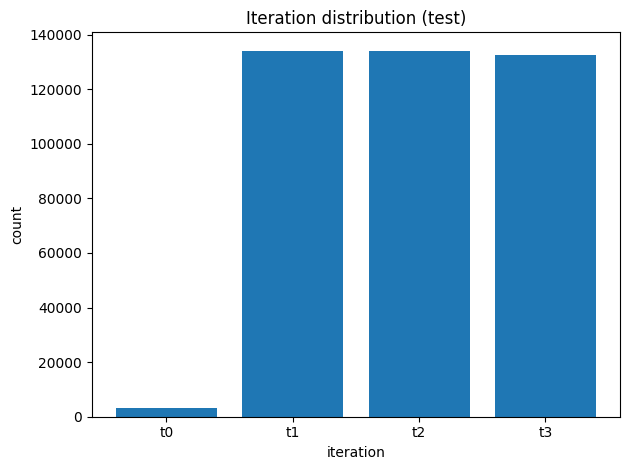

In [22]:
import matplotlib.pyplot as plt

counts_plot = {
    "t0": counts["t0_human"],
    "t1": counts["t1"],
    "t2": counts["t2"],
    "t3": counts["t3"],
}

plt.figure()
plt.bar(counts_plot.keys(), counts_plot.values())
plt.title("Iteration distribution (test)")
plt.xlabel("iteration")
plt.ylabel("count")
plt.tight_layout()

out = ROOT / "figures" / "decay_curves"
out.mkdir(parents=True, exist_ok=True)
plt.savefig(out / "iteration_distribution.png", dpi=200)
plt.show()

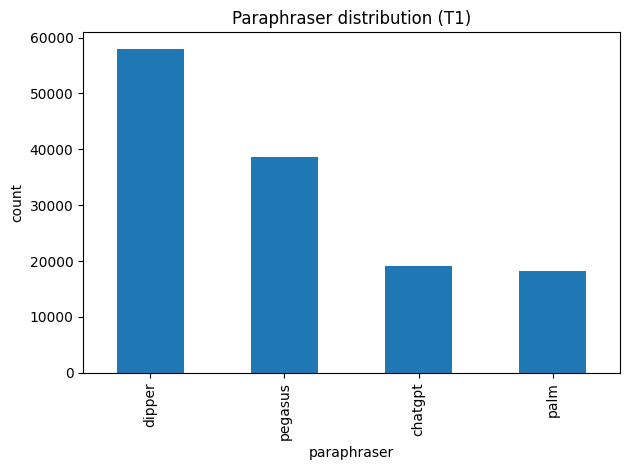

In [23]:
plt.figure()

para_counts = t1_all["paraphraser"].value_counts()
para_counts.plot(kind="bar")

plt.title("Paraphraser distribution (T1)")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(out / "paraphraser_distribution.png", dpi=200)
plt.show()